# Quantitative Metrics of Time-Series Benchmark

## Data Extraction / Preparation

### Pull Results from AGTS Paper

In [1]:
frameworks_to_pull = ['AutoARIMA', 'AutoETS', 'AutoPyTorch', 'AutoTheta', 'DeepAR', 'StatEnsemble', 'TFT']

In [2]:
import pandas as pd

# Read the CSV file into a DataFrame
csv_file_path = "./agts_benchmark_results.csv"
agts_res = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame to verify
agts_res.framework.unique()


array(['AutoARIMA', 'AutoETS', 'AutoGluon_bestquality',
       'AutoGluon_NoDeepModels', 'AutoGluon_NoEnsemble',
       'AutoGluon_NoStatModels', 'AutoGluon_NoTreeModels', 'AutoPyTorch',
       'AutoTheta', 'DeepAR', 'SeasonalNaive', 'StatEnsemble', 'TFT'],
      dtype=object)

In [3]:
agts_res = agts_res[['framework', 'task', 'mase', 'wql', 'predict_duration', 'training_duration']]
agts_res = agts_res[agts_res['framework'].isin(frameworks_to_pull)]

# Group by 'framework' and 'task' and calculate the mean of 'mase', 'wql', 'predict_duration', and 'training_duration' across different seeds
agts_res_avg = agts_res.groupby(['framework', 'task']).agg({
    'mase': 'mean',
    'wql': 'mean',
    'predict_duration': 'mean',
    'training_duration': 'mean'
}).reset_index()

### Our Evaluation Runs

In [4]:
import wandb

# Initialize API (make sure you're logged in or set the API key)
wandb.login()

# Replace with your entity, project, and run ID
api = wandb.Api()

# Get all runs of the project that didn't crash
runs = api.runs(
    "rl-sunflower/tabpfn-time-series",
    # filters={"$and": [{"state": "finished"}, {"group": {"$in": ["11546127", "11548929"]}}]}
    filters={"tags": {"$in": [
        # Seasonal Naive
        "baseline-seasonal-naive",

        # Vanilla TabPFN
        "naive-tabpfn",

        # Autogluon (without Chronos)
        "baseline-autogluon-no-chronos",     

        "tabpfn-diff",
        "tabpfn-ar",
        "tabpfn-ts-naive",
        "tabpfn-ts-sin-cos"
    ]}},   
)


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: liamsbhoo (rl-sunflower). Use `wandb login --relogin` to force relogin


In [5]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd

def fetch_run_data(run):
    history = run.history()
    
    if len(history) > 1:
        # get the first row
        history = history.iloc[-1:]
    return history

# time the following code
import time
start = time.time()

all_runs_data = []
with ThreadPoolExecutor(max_workers=8) as executor:  # Adjust 'max_workers' based on your network conditions
    futures = [executor.submit(fetch_run_data, run) for run in runs]
    for future in tqdm(as_completed(futures), total=len(futures)):
        all_runs_data.append(future.result())

df_all_runs = pd.concat(all_runs_data)
print("df_all_runs.shape:", df_all_runs.shape)

print(f"Time taken: {time.time() - start:.2f} seconds")


100%|██████████| 175/175 [00:10<00:00, 17.13it/s]

df_all_runs.shape: (175, 27)
Time taken: 11.49 seconds


In [6]:
# Preprocess data (convert to float, NaN value -> inf)
numerical_cols = ['mase', 'wql', 'predict_duration', 'training_duration', 'result']
for col in numerical_cols:
    df_all_runs[col] = df_all_runs[col].astype(float)
    # df_all_runs[col] = df_all_runs[col].fillna(float('inf')).replace([float('inf'), np.nan], np.nan).astype(float)


# Get relevant columns only
df_all_runs = df_all_runs[['framework', 'task', 'mase', 'wql', 'predict_duration', 'training_duration']]

if 'agts_res_avg' in locals():
    agts_res_avg = agts_res_avg[agts_res_avg['task'].isin(df_all_runs['task'])]
    df_all_runs = pd.concat([df_all_runs, agts_res_avg], ignore_index=True)
    
df_all_runs['total_duration'] = df_all_runs['predict_duration'] + df_all_runs['training_duration']
df_all_runs.drop(columns=['predict_duration', 'training_duration'], inplace=True)


# Sort by framework and task
df_all_runs = df_all_runs.sort_values(by=['framework', 'task'])

# Drop index
df_all_runs.reset_index(drop=True, inplace=True)

In [7]:
df_all_runs.dropna(inplace=True)

In [8]:
print(df_all_runs.to_string())


                framework                task       mase       wql  total_duration
0               AutoARIMA           car_parts   1.117700  1.589040         145.700
1               AutoARIMA            cif_2016   1.069340  0.016759          27.000
2               AutoARIMA        covid_deaths   6.028920  0.029771          85.500
4               AutoARIMA  electricity_weekly   3.009210  0.137897          18.600
5               AutoARIMA             fred_md   0.477626  0.055569         146.300
6               AutoARIMA            hospital   0.819971  0.057939          56.500
8               AutoARIMA          m1_monthly   1.152300  0.146264          92.100
9               AutoARIMA        m1_quarterly   1.770100  0.088410          19.600
10              AutoARIMA           m1_yearly   3.869860  0.159649          16.100
11              AutoARIMA          m3_monthly   0.934188  0.101795         239.200
12              AutoARIMA            m3_other   2.244910  0.035030          16.400
13  

## Plotting

### Utils Function

In [9]:
import numpy as np
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap(data, title, xlabel, ylabel, annot_format=".0f", cmap='YlOrRd', annot=None):
    """
    Plots a heatmap for given data.

    Parameters:
    - data: DataFrame containing the data to be plotted.
    - title: str, title of the heatmap.
    - xlabel: str, label for the x-axis.
    - ylabel: str, label for the y-axis.
    - annot_format: str, format string for annotations.
    - cmap: str, colormap used for heatmap.
    - annot: DataFrame or bool, annotations to be shown on the heatmap.
    """
    plt.figure(figsize=(25, 10))
    if annot is None:
        annot = data
    sns.heatmap(data, cmap=cmap, annot=annot, fmt=annot_format, mask=data.isna())
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()


def min_max_scaling(series):
    return (series - series.min()) / (series.max() - series.min())


def calculate_framework_metrics(df):
    """
    Calculate the following metrics for the given dataframe:
    1. Average rescaled MASE (across all tasks) for each framework
    2. Average rank (across all tasks) for each framework
    3. Champion count (number of times a framework had the best performance across all tasks)

    Parameters:
    df (pd.DataFrame): DataFrame containing the rescaled MASE values for each framework and task.

    Returns:
    pd.DataFrame: DataFrame with 'average_rescaled_mase', 'average_rank', and 'champion' for each framework.
    """
    frameworks = df.index
    df_metric = pd.DataFrame(index=frameworks, columns=['average_rescaled_mase', 'average_rank', 'champion'])

    df_metric['average_rescaled_mase'] = df.mean(axis=1)
    df_metric['average_rank'] = df.rank(axis=0, na_option='keep').mean(axis=1)
    df_metric['champion'] = (df.rank(axis=0, method='min', ascending=True) == 1).sum(axis=1)
    
    return df_metric

### MASE Comparison (for Point Forecasting)

In [10]:
for framework in df_all_runs['framework'].unique():
    print(framework)
    print(df_all_runs[df_all_runs['framework'] == framework])
    print("\n")

AutoARIMA
    framework                task      mase       wql  total_duration
0   AutoARIMA           car_parts  1.117700  1.589040           145.7
1   AutoARIMA            cif_2016  1.069340  0.016759            27.0
2   AutoARIMA        covid_deaths  6.028920  0.029771            85.5
4   AutoARIMA  electricity_weekly  3.009210  0.137897            18.6
5   AutoARIMA             fred_md  0.477626  0.055569           146.3
6   AutoARIMA            hospital  0.819971  0.057939            56.5
8   AutoARIMA          m1_monthly  1.152300  0.146264            92.1
9   AutoARIMA        m1_quarterly  1.770100  0.088410            19.6
10  AutoARIMA           m1_yearly  3.869860  0.159649            16.1
11  AutoARIMA          m3_monthly  0.934188  0.101795           239.2
12  AutoARIMA            m3_other  2.244910  0.035030            16.4
13  AutoARIMA        m3_quarterly  1.418900  0.078723            31.8
14  AutoARIMA           m3_yearly  3.158520  0.161650            21.4
15  AutoAR

In [11]:
# Calculate normalized MASE (one entry for each task, normalized across framework)
df_all_runs['normalized_mase'] = df_all_runs.groupby('task')['mase'].transform(min_max_scaling)

In [12]:
df_all_runs.pivot(index='framework', columns='task', values='mase')

task,car_parts,cif_2016,covid_deaths,electricity_hourly,electricity_weekly,fred_md,hospital,kdd_cup_2018,m1_monthly,m1_quarterly,...,m4_daily,m4_hourly,m4_weekly,nn5_daily,nn5_weekly,pedestrian_counts,tourism_monthly,tourism_quarterly,tourism_yearly,vehicle_trips
framework,,,,,,,,,,,,,,,,,,,,,
AutoARIMA,1.117700,1.069340,6.028920,NaN,3.009210,0.477626,0.819971,NaN,1.152300,1.770100,...,1.152770,1.028890,2.354940,0.934769,0.997639,NaN,1.584830,1.655260,4.044240,1.427180
AutoETS,1.133140,0.897635,5.907220,1.465330,3.076440,0.504835,0.765814,0.987534,1.082580,1.665310,...,1.227580,1.609400,2.547880,0.869630,0.979970,0.552707,1.529220,1.577530,3.183190,1.300920
AutoGluon,0.747569,0.946028,5.851320,0.955928,2.060200,0.579001,0.750466,0.772941,1.000710,1.603630,...,1.160760,0.813971,2.035130,0.763856,0.848458,0.331411,1.424730,1.530040,3.004930,1.114360
AutoPyTorch,0.746424,1.023332,4.910562,1.420178,2.321640,0.681661,0.769910,0.763643,1.278040,1.812990,...,1.151890,1.344526,2.369304,0.807448,0.865151,0.354435,1.495174,1.646536,3.003903,1.161838
AutoTheta,1.207800,1.006370,7.718560,NaN,3.113280,0.564183,0.763705,1.009810,1.091740,1.667040,...,1.149110,2.455880,2.608480,0.878089,0.963435,NaN,1.665550,1.648100,2.991720,1.284360
DeepAR,0.749314,1.277910,7.166274,1.251064,2.447202,0.633507,0.771033,0.841063,1.117396,1.741668,...,1.144760,1.484034,2.417562,0.812498,0.915464,0.309459,1.460662,1.599448,3.475696,1.161598
SeasonalNaive,1.126880,1.289290,8.977360,1.230110,3.037170,1.100800,0.920528,0.975216,1.314460,2.077540,...,1.451780,1.193210,2.777300,1.011280,1.062850,0.369195,1.630940,1.698990,3.552010,1.302230
StatEnsemble,1.052410,0.944657,5.883990,NaN,3.077140,0.497532,0.753469,NaN,1.045090,1.622490,...,1.145380,1.156740,2.375040,0.859283,0.977178,NaN,1.469180,1.539230,3.230730,1.203400
TFT,0.750865,1.371766,5.192000,1.389350,2.861048,0.900660,0.814139,0.843934,1.534078,2.099048,...,1.176152,3.390952,2.624740,0.789385,0.884258,0.373357,1.718514,1.830222,2.915920,1.227150


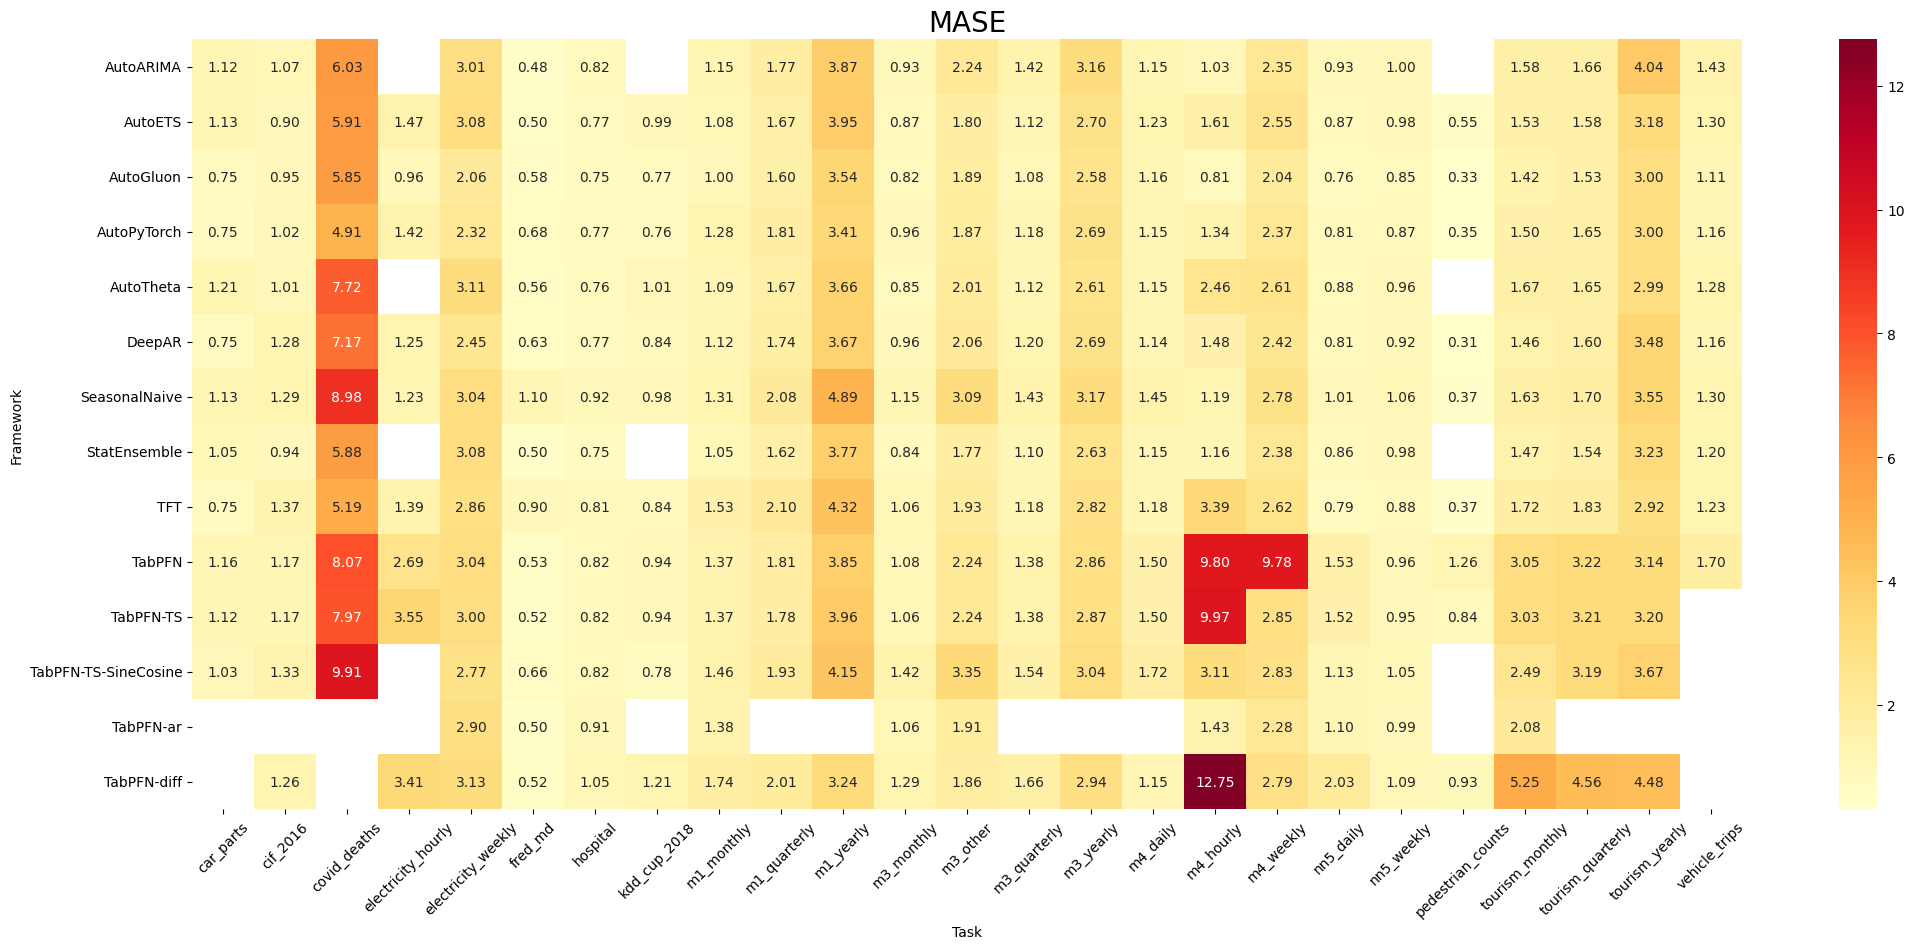

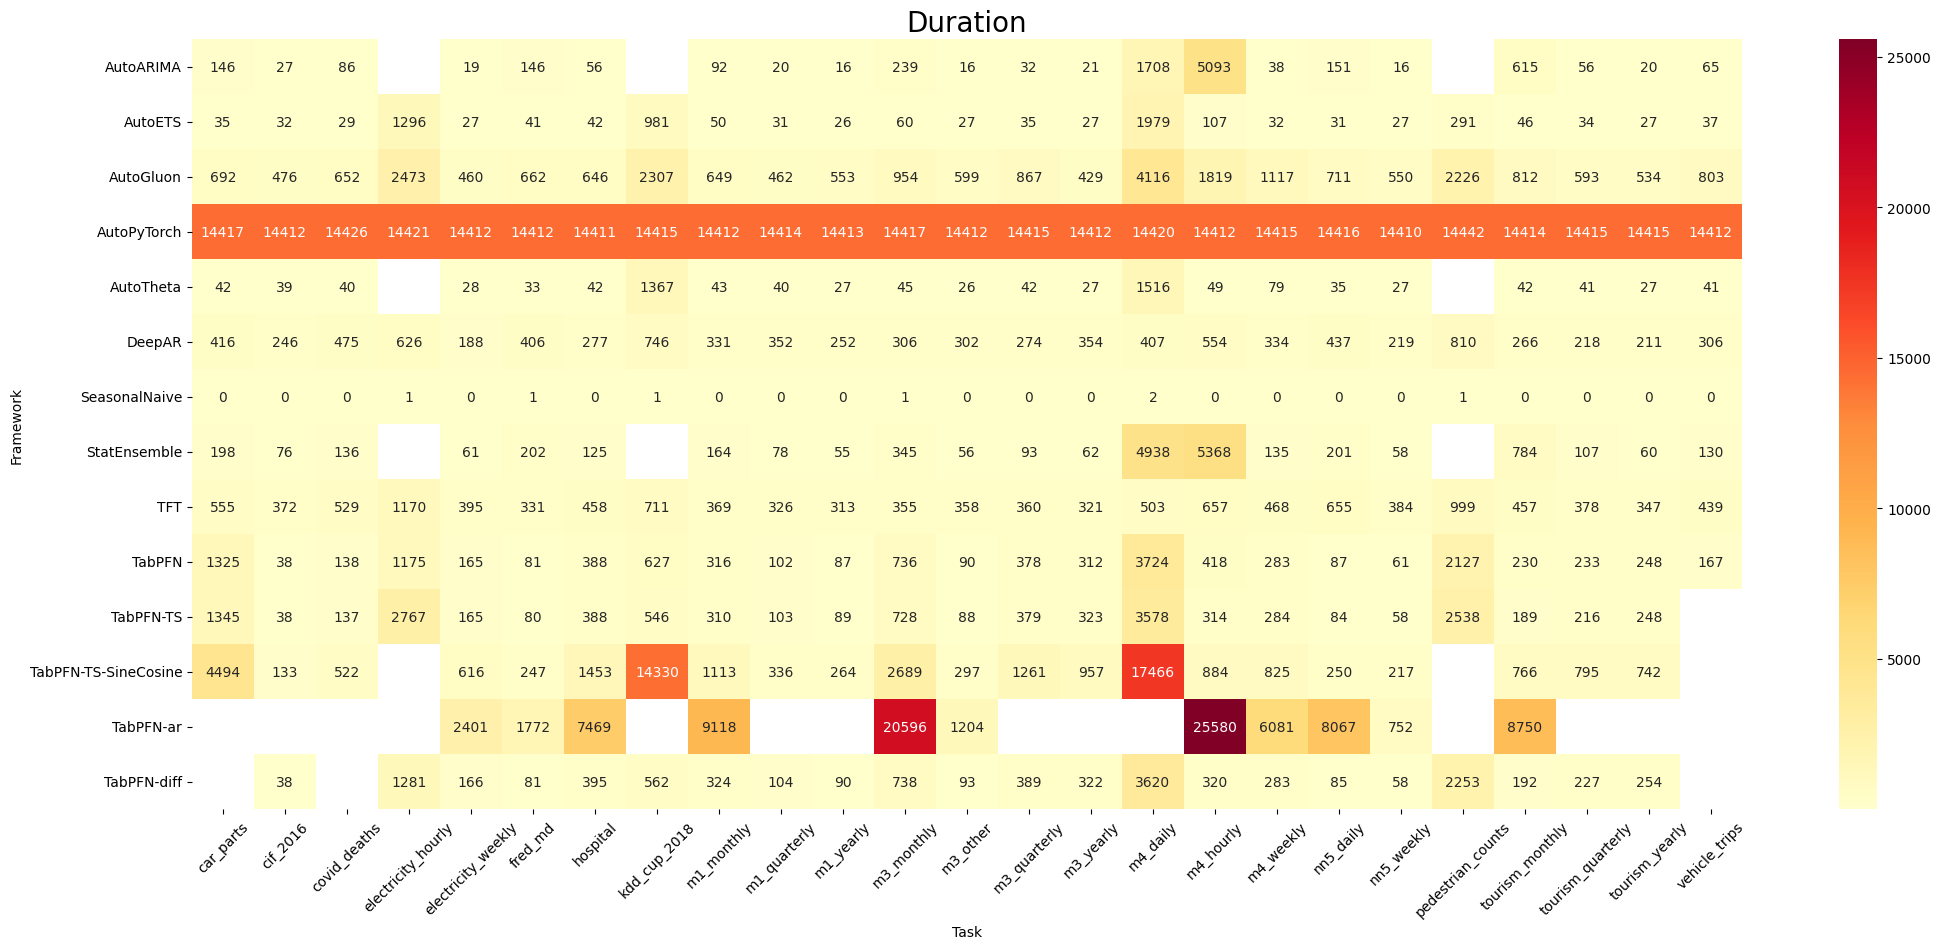

In [13]:
# Create Pivot tables for plotting
df_mase_pivot = df_all_runs.pivot(index='framework', columns='task', values='mase')

# Customized annotation (each cell should be value of mase and total duration as a subtext)
df_duration_pivot = df_all_runs.pivot(index='framework', columns='task', values='total_duration')
df_mase_annot = df_mase_pivot.round(2).astype(str) + "\n(" + df_duration_pivot.fillna(-1).astype(int).astype(str) + "s)"


plot_heatmap(df_mase_pivot, "MASE", "Task", "Framework", annot_format="0.2f")
plot_heatmap(df_duration_pivot, "Duration", "Task", "Framework")


### Normalized MASE (for Point Forecasting)

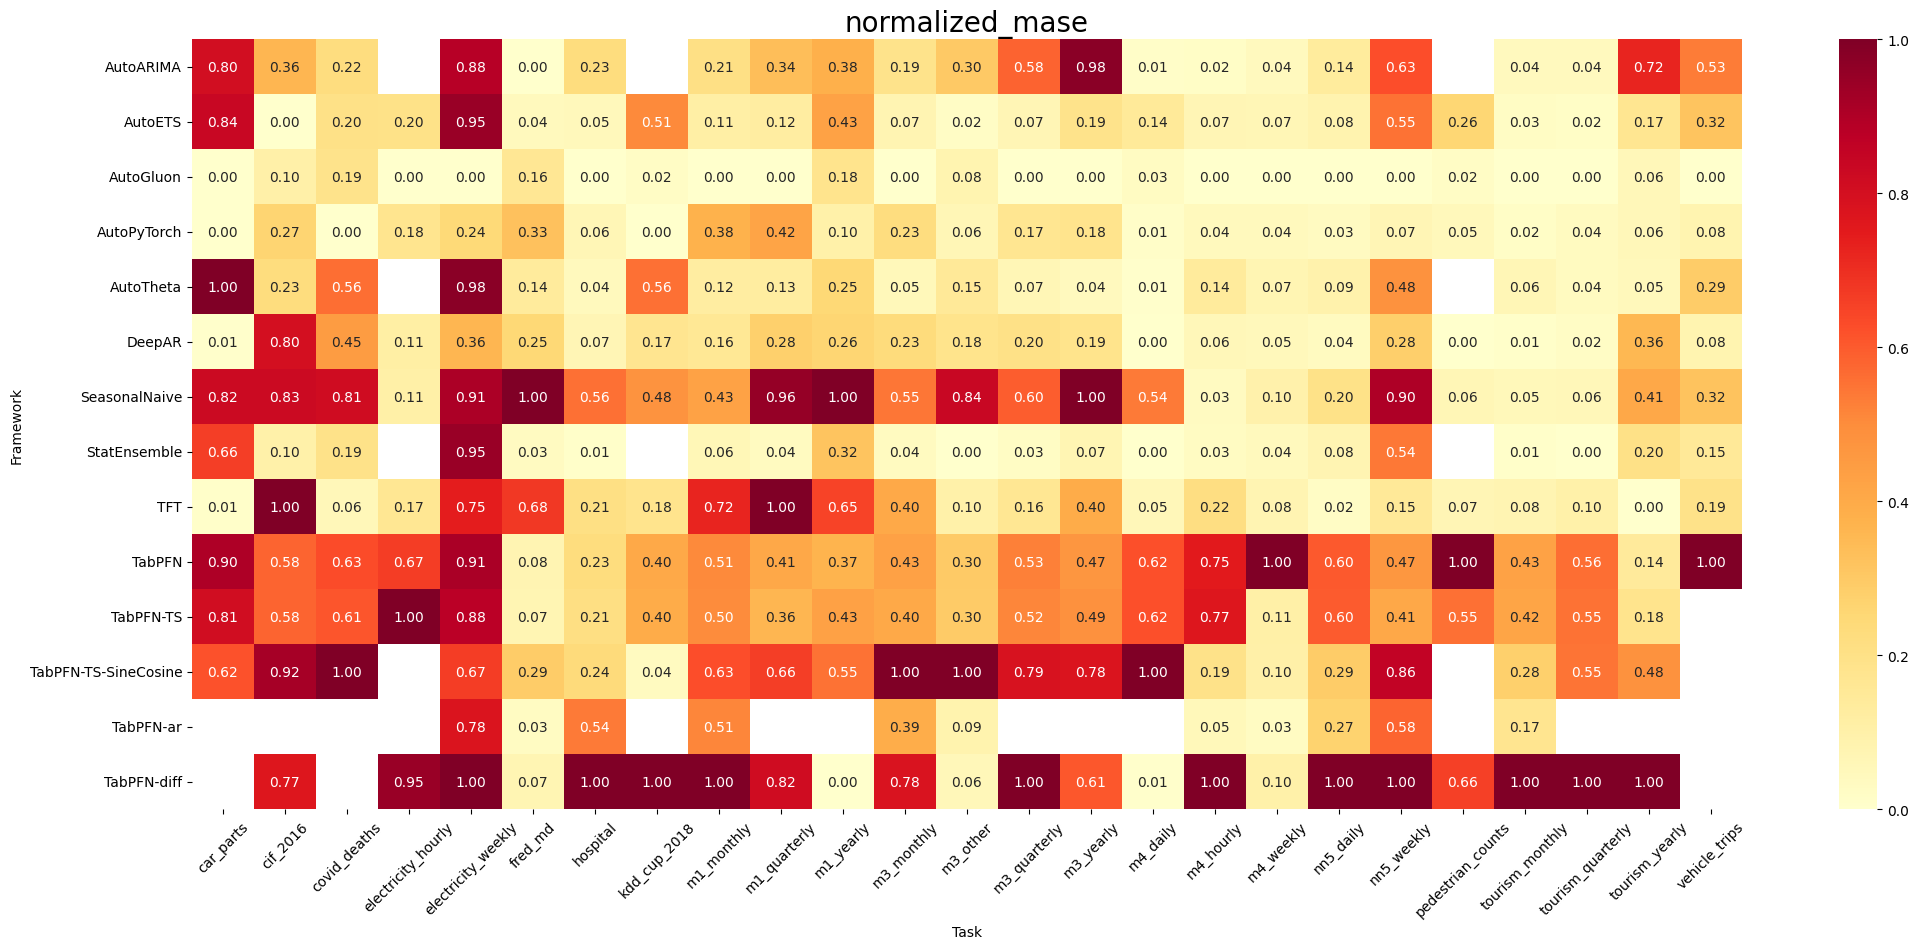

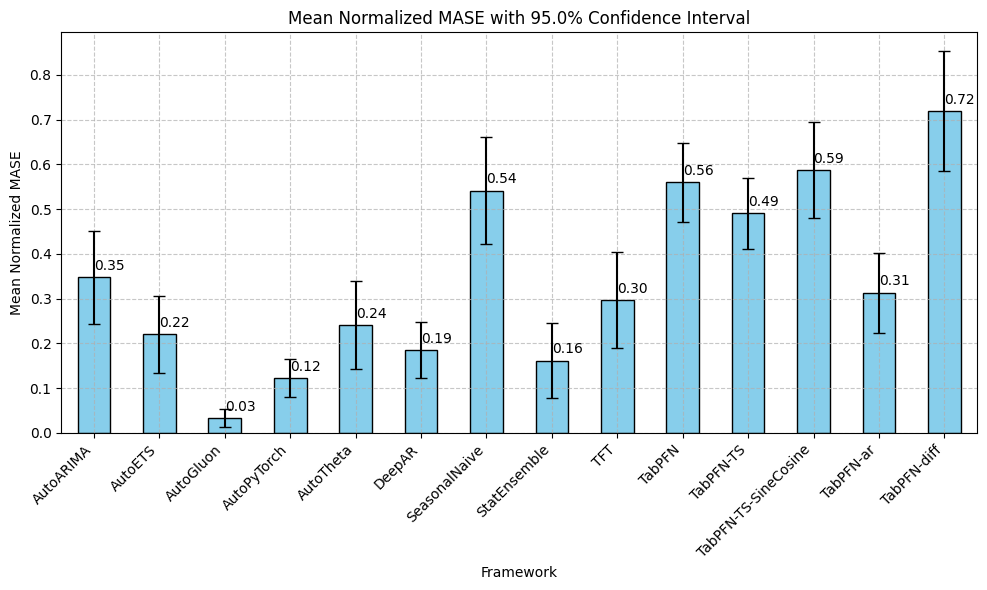

In [14]:
import numpy as np
from scipy.stats import t

df_norm_mase_pivot = df_all_runs.pivot(index='framework', columns='task', values='normalized_mase')
plot_heatmap(df_norm_mase_pivot, "normalized_mase", "Task", "Framework", annot_format=".2f")

def plot_mean_and_confidence_interval(df_pivot, confidence_level=0.95):
    mean_norm_mase = df_pivot.mean(axis=1)
    std_norm_mase = df_pivot.std(axis=1)
    confidence_interval = t.ppf(confidence_level, df_pivot.shape[1] - 1) * (std_norm_mase / np.sqrt(df_pivot.shape[1]))
    
    # Plot the mean and confidence interval
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = mean_norm_mase.plot(kind='bar', yerr=confidence_interval, ax=ax, capsize=4, color='skyblue', edgecolor='black')

    # Add value annotations on the bars
    for bar in bars.patches:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height), 
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points", 
                    ha='left', va='bottom')

    # Customize the plot
    ax.set_title(f'Mean Normalized MASE with {confidence_level * 100}% Confidence Interval')
    ax.set_xlabel('Framework')
    ax.set_ylabel('Mean Normalized MASE')
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

confidence_level = 0.95
plot_mean_and_confidence_interval(df_norm_mase_pivot, confidence_level)


### Aggregated Metrics (for Point Forecasting)

In [15]:
calculate_framework_metrics(df_norm_mase_pivot)

,average_rescaled_mase,average_rank,champion
framework,,,
AutoARIMA,0.347800,7.272727,1
AutoETS,0.219991,5.880000,1
AutoGluon,0.033750,2.200000,15
AutoPyTorch,0.122619,4.280000,3
AutoTheta,0.241681,6.217391,0
DeepAR,0.185016,5.160000,2
SeasonalNaive,0.541569,9.680000,0
StatEnsemble,0.161690,3.954545,1
TFT,0.297602,7.280000,1
